In [2]:
from torchvision import datasets, transforms
transform = transforms.Compose([transforms.ToTensor()])
mnist = datasets.MNIST(root="./data", train=True, download=True, transform=transform)

In [3]:
import numpy as np
data = np.asarray(mnist.data)
data[0].shape

(28, 28)

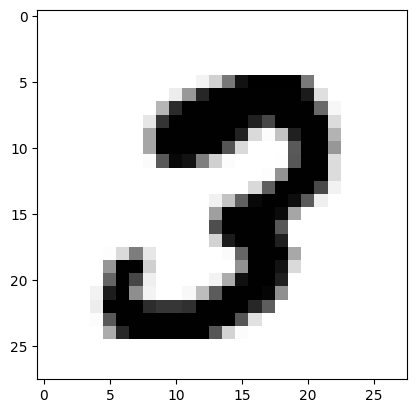

In [4]:
import matplotlib.pyplot as plt
plt.imshow(data[12345], cmap='grey_r')

In [5]:
labels = np.asarray(mnist.train_labels)

c:\Users\Bryant Willoughby\AppData\Local\Programs\Python\Python313\Lib\site-packages\torchvision\datasets\mnist.py:66: UserWarning: train_labels has been renamed targets
  warnings.warn("train_labels has been renamed targets")


In [6]:
X = data
X = X.reshape(60000, 28 * 28)

In [7]:
import torch
Xm = X.mean(axis=0)
Xc = X - Xm

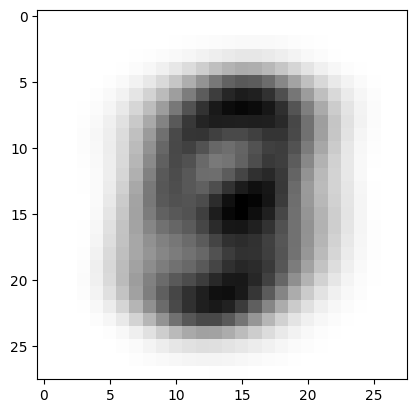

In [8]:
plt.imshow(Xm.reshape(28, 28), cmap="grey_r")

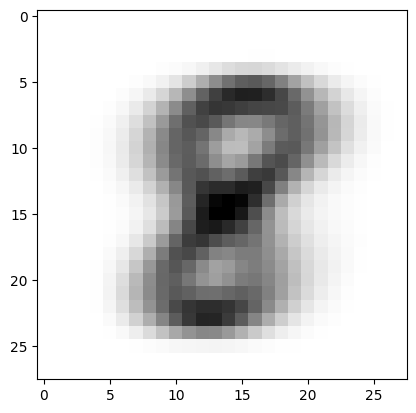

In [9]:
X3 = X[labels == 8]
X3.shape
X3m = X3.mean(axis=0).reshape(28, 28)
plt.imshow(X3m, cmap="grey_r")

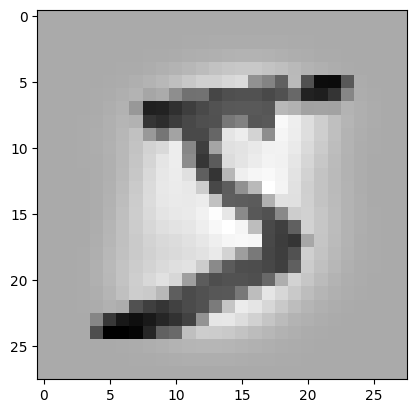

In [10]:
plt.imshow(Xc[0].reshape(28, 28), cmap="grey_r")

In [11]:
U, S, Vt = np.linalg.svd(X, full_matrices=False)

In [12]:
coords = U @ np.diag(S)

In [13]:
x = coords[:, 0]
y = coords[:, 1]

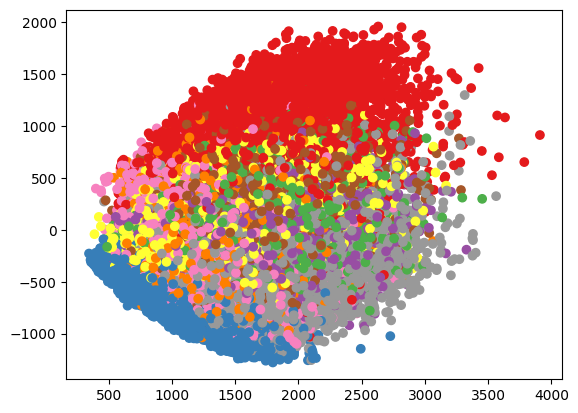

In [14]:
plt.scatter(x, y, c=labels, cmap="Set1")

In [15]:
y = labels % 2
labels[:5], y[:5]

(array([5, 0, 4, 1, 9]), array([1, 0, 0, 1, 1]))

In [16]:
def classifier(X, w, b):
    # w.shape == (784,)
    # b.shape == ()
    z = X @ w + b
    # sigmoid = 1 / (1 + exp(-x))
    return torch.sigmoid(z)

w = torch.randn(784) / 784
b = torch.randn(())

Xt = torch.tensor(Xc, dtype=torch.float32)
yt = torch.tensor(y, dtype=torch.float32)

In [17]:
i = 0

In [19]:
i += 1
classifier(Xt[i], w, b), y[i]

(tensor(0.8533), np.int64(0))

In [20]:
w = torch.randn(784, requires_grad=True)
b = torch.randn((), requires_grad=True)

Xt = torch.tensor(Xc, dtype=torch.float32)
yt = torch.tensor(y, dtype=torch.float32)

def loss_fn(w, b, X, y):
    z = X @ w + b
    return torch.nn.functional.binary_cross_entropy_with_logits(z, y)

opt = torch.optim.SGD([w, b], lr=0.01)
for i in range(1000):
    opt.zero_grad()
    loss = loss_fn(w, b, Xt, yt)
    loss.backward()
    opt.step()
    if i % 100 == 0:
        print(loss)

tensor(813.2368, grad_fn=<BinaryCrossEntropyWithLogitsBackward0>)
tensor(51.4174, grad_fn=<BinaryCrossEntropyWithLogitsBackward0>)
tensor(33.8142, grad_fn=<BinaryCrossEntropyWithLogitsBackward0>)
tensor(26.7021, grad_fn=<BinaryCrossEntropyWithLogitsBackward0>)
tensor(26.4916, grad_fn=<BinaryCrossEntropyWithLogitsBackward0>)
tensor(26.8427, grad_fn=<BinaryCrossEntropyWithLogitsBackward0>)
tensor(27.0566, grad_fn=<BinaryCrossEntropyWithLogitsBackward0>)
tensor(26.5569, grad_fn=<BinaryCrossEntropyWithLogitsBackward0>)
tensor(24.8666, grad_fn=<BinaryCrossEntropyWithLogitsBackward0>)
tensor(23.8670, grad_fn=<BinaryCrossEntropyWithLogitsBackward0>)


In [21]:
def classify(x):
    return torch.sigmoid(x.dot(w) + b)
i = 0

In [22]:
i += 1
classify(Xt[i]), yt[i]

(tensor(0., grad_fn=<SigmoidBackward0>), tensor(0.))

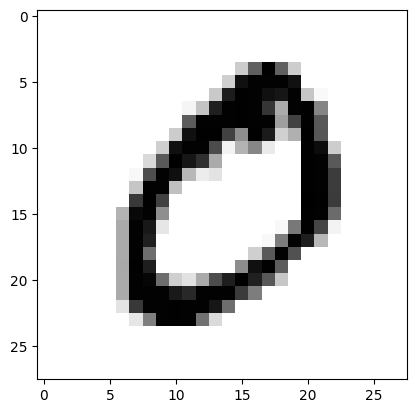

In [23]:
plt.imshow(X[i].reshape(28, 28), cmap="grey_r")